In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [95]:
df=pd.read_csv('../data/churn_prob.csv')

In [96]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Probability
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0.816891
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0.095735
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.521023
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0.058477
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0.862878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,0.214549
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,0.305084
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,0.621355
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0.858786


In [97]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Probability"
]

In [98]:
from sklearn.preprocessing import StandardScaler

segment_data = df[features]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_data)

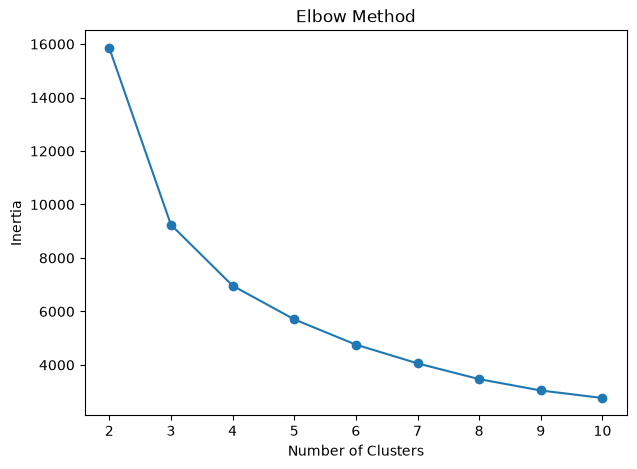

In [99]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [100]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Segment"] = kmeans.fit_predict(scaled_data)

In [101]:
df.groupby("Segment")[features].mean().round(2)

,tenure,MonthlyCharges,TotalCharges,Churn_Probability
Segment,,,,
0,48.53,37.88,1785.90,0.08
1,14.99,83.63,1300.04,0.76
2,60.39,93.66,5659.28,0.26
3,9.51,35.71,358.97,0.43


In [102]:
segment_names = {
    0: "Loyal Long-Term Customers",
    1: "High-Risk Premium Customers",
    2: "Premium Loyal Customers",
    3: "New Low-Value Customers"
}



In [103]:
df["Segment_Name"] = df["Segment"].map(segment_names)

In [104]:
df["Segment_Name"].value_counts()

Segment_Name
High-Risk Premium Customers    2048
Premium Loyal Customers        1780
New Low-Value Customers        1697
Loyal Long-Term Customers      1518
Name: count, dtype: int64

In [105]:
df["Segment_Name"] = df["Segment"].map(segment_names)

In [106]:
df["Segment_Name"].value_counts(normalize=True) * 100

Segment_Name
High-Risk Premium Customers    29.078518
Premium Loyal Customers        25.273321
New Low-Value Customers        24.094846
Loyal Long-Term Customers      21.553315
Name: proportion, dtype: float64

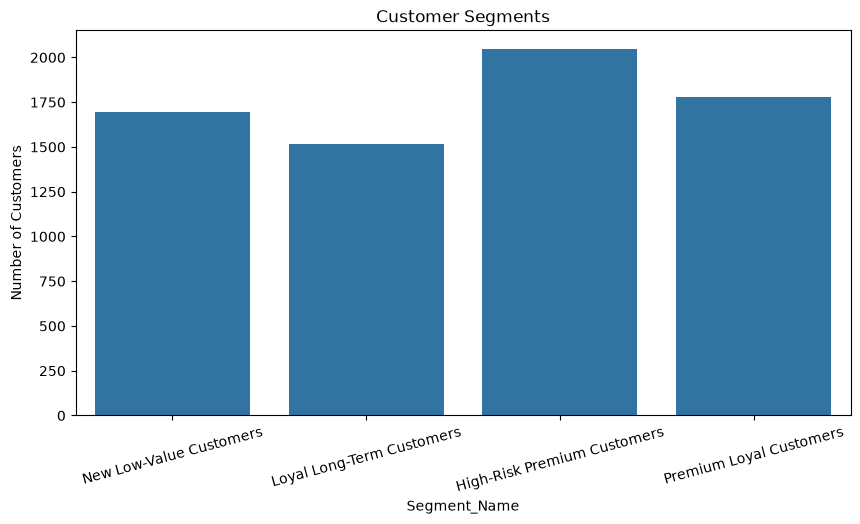

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x="Segment_Name")

plt.title("Customer Segments")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [108]:
df["Risk_Level"] = pd.cut(
    df["Churn_Probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

In [109]:
def priority(prob):
    if prob >= 0.7:
        return "Critical"
    elif prob >= 0.4:
        return "High"
    else:
        return "Normal"

df["Priority"] = df["Churn_Probability"].apply(priority)

In [110]:
def retention_action(row):

    if row["Segment_Name"] == "High-Risk Premium Customers":
        return "Proactive Discount + Priority Suppor"

    elif row["Segment_Name"] == "Premium Loyal Customers":
        return "VIP Rewards & Exclusive Loyalty Benefits"

    elif row["Segment_Name"] == "Loyal Long-Term Customers":
        return "Personalized Upsell & Cross-Sell Offers"

    elif row["Segment_Name"] == "New Low-Value Customers":
        return "Welcome Offer + Onboarding Support "

    else:
        return "Regular Customer Engagement"

df["Retention_Action"] = df.apply(retention_action, axis=1)

In [111]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Probability,Segment,Segment_Name,Risk_Level,Priority,Retention_Action
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,0,0.816891,3,New Low-Value Customers,High,Critical,Welcome Offer + Onboarding Support
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,0,0.095735,0,Loyal Long-Term Customers,Low,Normal,Personalized Upsell & Cross-Sell Offers
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,0.521023,3,New Low-Value Customers,Medium,High,Welcome Offer + Onboarding Support
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,0,0.058477,0,Loyal Long-Term Customers,Low,Normal,Personalized Upsell & Cross-Sell Offers
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,0.862878,1,High-Risk Premium Customers,High,Critical,Proactive Discount + Priority Suppor


In [113]:
df.to_csv("../data/Final_Segments.csv", index=False)